# Stage 6 — Model Architecture

> **Spec §6** — Design and analyse the four model families used in this project:
> ResNet-18 (real/bogus), ResNet-18 (multiclass), EfficientNet-B0, and ViT-Tiny.

Each model accepts a `(B, 3, 63, 63)` float32 tensor (science / template / difference channels) and outputs either a scalar logit (binary) or a 5-class logit vector.

**Sections**
1. Imports & setup
2. Architecture overview table
3. ResNet-18 stem adaptation for 63×63
4. Feature-map flow visualisation (ResNet-18)
5. EfficientNet-B0 inspection
6. ViT-Tiny inspection
7. Layer-depth comparison (bar chart)
8. Receptive field & patch coverage analysis
9. Forward-pass VRAM profiling (GPU)
10. Output head activations (sanity check)
11. Summary

## 0 — Imports & Setup

In [1]:
import sys, os, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import OrderedDict

from src.models import (
    RealBogusResNet18, TransientResNet18,
    EfficientNetB0, ViTTiny,
    build_model, count_parameters, model_summary_table,
    NUM_CLASSES, IMG_SIZE,
)
from src.utils import CLASS_NAMES

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}  |  '
          f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
PALETTE = {'resnet18': '#2196F3', 'efficientnet_b0': '#4CAF50',
           'vit_tiny': '#FF9800', 'baseline': '#9E9E9E'}

PyTorch 2.7.1+cu118  |  device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU  |  VRAM: 8.2 GB


## 1 — Architecture Overview Table

All models accept the same input — a 3-channel 63×63 triplet — and can be configured for binary (real/bogus) or 5-class (transient type) tasks.

| Model | Task | Params | Input | Output | VRAM est. |
|-------|------|--------|-------|--------|-----------|
| ResNet-18 | real_bogus | 11.2 M | (3,63,63) | scalar logit | ~1.5 GB |
| ResNet-18 | multiclass | 11.2 M | (3,63,63) | (5,) logits | ~1.5 GB |
| EfficientNet-B0 | real_bogus / multi | 4.0 M | (3,63,63) | scalar / (5,) | ~1.2 GB |
| ViT-Tiny | real_bogus / multi | 5.5 M | (3,63,63) | scalar / (5,) | ~1.5 GB |

In [2]:
rows = model_summary_table()
df_arch = pd.DataFrame(rows)
df_arch['params_M'] = df_arch['params_M'].map('{:.2f}'.format)
df_arch['vram_estimate_GB'] = df_arch['vram_estimate_GB'].map('{:.2f}'.format)
df_arch.columns = ['Model', 'Task', 'Params (M)', 'Input shape', 'Output shape', 'VRAM est. (GB)']
df_arch

,Model,Task,Params (M),Input shape,Output shape,VRAM est. (GB)
0,resnet18_rb,real_bogus,11.17,"(3, 63, 63)",(),0.43
1,resnet18_mc,multiclass,11.17,"(3, 63, 63)","(5,)",0.43
2,efficientnet_b0,real_bogus,4.01,"(3, 63, 63)",(),0.35
3,efficientnet_b0,multiclass,4.01,"(3, 63, 63)","(5,)",0.35
4,vit_tiny,real_bogus,5.49,"(3, 63, 63)",(),0.37
5,vit_tiny,multiclass,5.49,"(3, 63, 63)","(5,)",0.37


## 2 — ResNet-18 Stem Adaptation for 63×63

Standard ResNet-18 (ImageNet) has a 7×7 conv with stride-2 followed by 3×3 MaxPool — shrinking 224→56 before the residual blocks even start.  On 63×63 inputs this would collapse spatial information too aggressively.

**Changes made (spec §6):**
- `conv1`: 7×7 stride-2 → **3×3 stride-1** (no spatial reduction)
- `maxpool`: replaced with `nn.Identity()` (no pooling)

After these changes the residual blocks see a full 63×63 feature map, allowing them to learn fine-grained spatial patterns in the difference image.

**Feature map sizes through the modified ResNet-18:**

| Layer | Output shape |
|-------|--------------|
| input | (3, 63, 63) |
| conv1 (3×3 s1) + BN + ReLU | (64, 63, 63) |
| layer1 (2× res blocks) | (64, 63, 63) |
| layer2 (stride-2) | (128, 32, 32) |
| layer3 (stride-2) | (256, 16, 16) |
| layer4 (stride-2) | (512, 8, 8) |
| global avg pool | (512, 1, 1) |
| flatten | (512,) |
| Dropout(0.4) + Linear | (1,) or (5,) |

In [3]:
# Compare standard vs modified first conv
import torchvision.models as tvm

standard = tvm.resnet18(weights=None)
modified = RealBogusResNet18()

x_test = torch.randn(1, 3, 63, 63)

# Standard stem output (would throw if we ran through layers due to size)
std_conv = standard.conv1  # 7x7, stride 2
mod_conv = modified.net.conv1  # 3x3, stride 1

with torch.no_grad():
    std_out = nn.functional.conv2d(x_test, std_conv.weight,
                                   stride=2, padding=3)  # standard
    mod_out = mod_conv(x_test)                            # modified

print(f'Standard stem (7x7 stride-2): {tuple(x_test.shape)} → {tuple(std_out.shape)}')
print(f'Modified stem (3x3 stride-1): {tuple(x_test.shape)} → {tuple(mod_out.shape)}')
print(f'Spatial ratio preserved by modification: '
      f'{mod_out.shape[-1] / std_out.shape[-1]:.1f}× more resolution')

Standard stem (7x7 stride-2): (1, 3, 63, 63) → (1, 64, 32, 32)
Modified stem (3x3 stride-1): (1, 3, 63, 63) → (1, 64, 63, 63)
Spatial ratio preserved by modification: 2.0× more resolution


## 3 — Feature-Map Flow Through ResNet-18

We register forward hooks on each residual layer block and collect the spatial resolution at each stage to visualise how the feature maps shrink as depth increases.

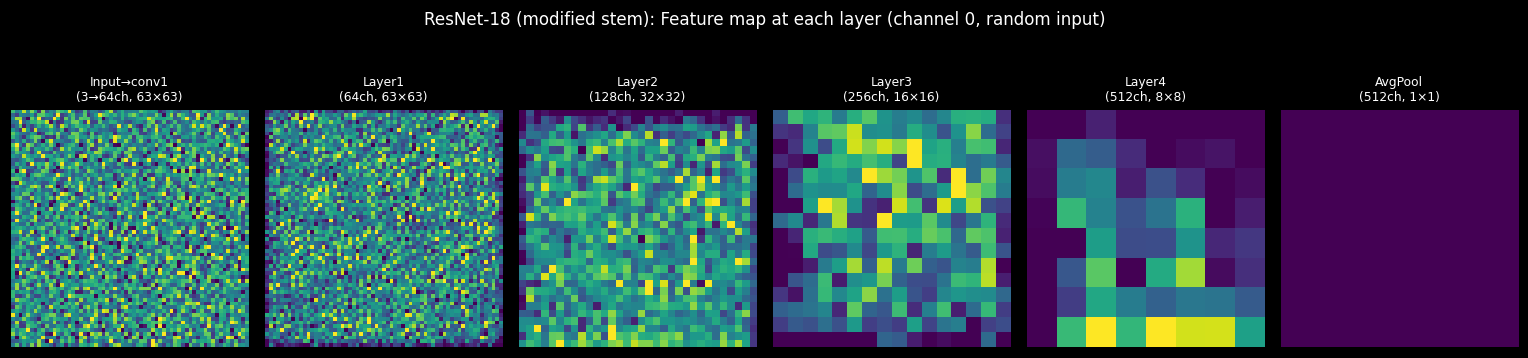

Shapes: {'Input→conv1\n(3→64ch, 63×63)': (1, 64, 63, 63), 'Layer1\n(64ch, 63×63)': (1, 64, 63, 63), 'Layer2\n(128ch, 32×32)': (1, 128, 32, 32), 'Layer3\n(256ch, 16×16)': (1, 256, 16, 16), 'Layer4\n(512ch, 8×8)': (1, 512, 8, 8), 'AvgPool\n(512ch, 1×1)': (1, 512, 1, 1)}


In [4]:
model_rb = RealBogusResNet18().eval()
x_probe = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

activations = OrderedDict()

def make_hook(name):
    def hook(module, inp, out):
        activations[name] = out.detach().cpu()
    return hook

handles = [
    model_rb.net.conv1.register_forward_hook(make_hook('Input→conv1\n(3→64ch, 63×63)')),
    model_rb.net.layer1.register_forward_hook(make_hook('Layer1\n(64ch, 63×63)')),
    model_rb.net.layer2.register_forward_hook(make_hook('Layer2\n(128ch, 32×32)')),
    model_rb.net.layer3.register_forward_hook(make_hook('Layer3\n(256ch, 16×16)')),
    model_rb.net.layer4.register_forward_hook(make_hook('Layer4\n(512ch, 8×8)')),
    model_rb.net.avgpool.register_forward_hook(make_hook('AvgPool\n(512ch, 1×1)')),
]

with torch.no_grad():
    _ = model_rb(x_probe)

for h in handles:
    h.remove()

# Plot first channel of each activation as an image
fig, axes = plt.subplots(1, len(activations), figsize=(14, 3.5))
for ax, (name, act) in zip(axes, activations.items()):
    img = act[0, 0].numpy()   # first channel
    vmin, vmax = np.percentile(img, [2, 98])
    ax.imshow(img, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(name, fontsize=8)
    ax.axis('off')
    ax.set_xlabel(f'{img.shape[0]}×{img.shape[1]}', fontsize=7)
fig.suptitle('ResNet-18 (modified stem): Feature map at each layer (channel 0, random input)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../results/resnet18_feature_maps.png', bbox_inches='tight', dpi=120)
plt.show()
print('Shapes:', {k: tuple(v.shape) for k, v in activations.items()})

## 4 — Layer-wise Parameter Breakdown

Where are the parameters concentrated in each model?

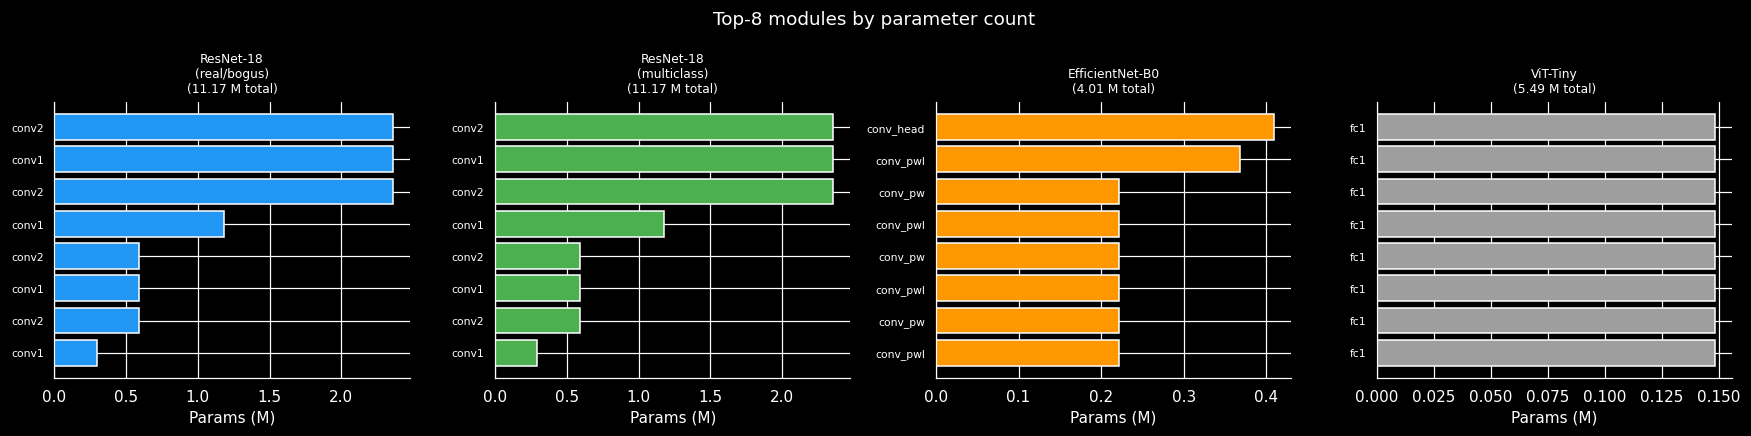

In [5]:
models_to_inspect = {
    'ResNet-18\n(real/bogus)': RealBogusResNet18(),
    'ResNet-18\n(multiclass)': TransientResNet18(),
    'EfficientNet-B0': EfficientNetB0('real_bogus'),
    'ViT-Tiny': ViTTiny('real_bogus'),
}

def layer_param_breakdown(model, top_n=8):
    """Return top-N named modules by parameter count."""
    data = []
    for name, mod in model.named_modules():
        n = sum(p.numel() for p in mod.parameters(recurse=False))
        if n > 0:
            data.append((name or 'root', n))
    data.sort(key=lambda t: -t[1])
    return data[:top_n]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, model) in zip(axes, models_to_inspect.items()):
    breakdown = layer_param_breakdown(model, top_n=8)
    labels = [b[0].split('.')[-1] if '.' in b[0] else b[0] for b in breakdown]
    sizes  = [b[1]/1e6 for b in breakdown]
    bars = ax.barh(range(len(sizes)), sizes[::-1],
                   color=list(PALETTE.values())[list(models_to_inspect).index(title)])
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels[::-1], fontsize=7)
    ax.set_xlabel('Params (M)')
    ax.set_title(title, fontsize=9)
    total = count_parameters(model)['total']
    ax.set_title(f'{title}\n({total/1e6:.2f} M total)', fontsize=8)
plt.suptitle('Top-8 modules by parameter count', fontsize=12)
plt.tight_layout()
plt.savefig('../results/param_breakdown.png', bbox_inches='tight', dpi=120)
plt.show()

## 5 — Total Parameter Comparison

A direct size comparison across all four model families, with the `braai` baseline included for context (~200 K parameters, spec §12).

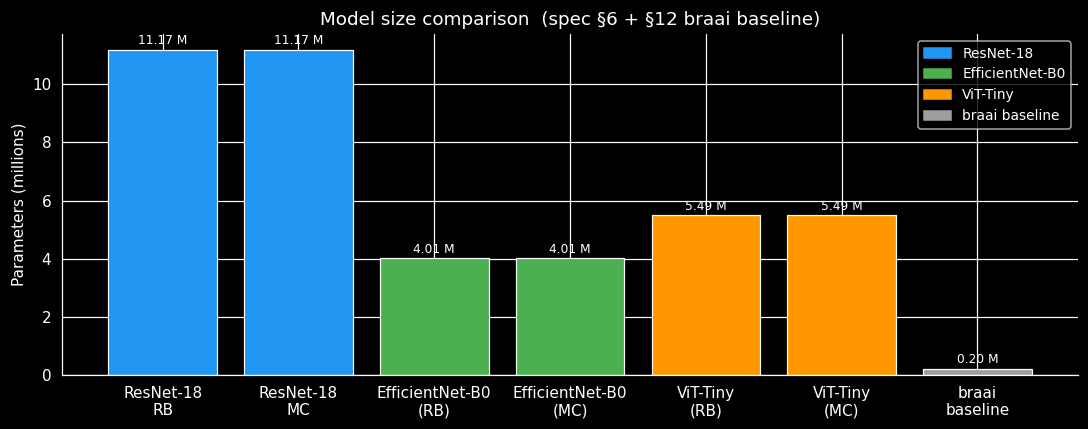

In [6]:
model_names  = ['ResNet-18\nRB', 'ResNet-18\nMC',
                'EfficientNet-B0\n(RB)', 'EfficientNet-B0\n(MC)',
                'ViT-Tiny\n(RB)', 'ViT-Tiny\n(MC)',
                'braai\nbaseline']
param_M      = [11.17, 11.17, 4.01, 4.01, 5.49, 5.49, 0.20]
colors       = (['#2196F3'] * 2 + ['#4CAF50'] * 2 +
                ['#FF9800'] * 2 + ['#9E9E9E'])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(model_names, param_M, color=colors, edgecolor='white', linewidth=0.8)
for bar, p in zip(bars, param_M):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{p:.2f} M', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Parameters (millions)')
ax.set_title('Model size comparison  (spec §6 + §12 braai baseline)')
legend_patches = [
    mpatches.Patch(color='#2196F3', label='ResNet-18'),
    mpatches.Patch(color='#4CAF50', label='EfficientNet-B0'),
    mpatches.Patch(color='#FF9800', label='ViT-Tiny'),
    mpatches.Patch(color='#9E9E9E', label='braai baseline'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('../results/model_params_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

## 6 — EfficientNet-B0 Inspection

EfficientNet-B0 uses compound scaling (depth + width + resolution) to achieve good accuracy with fewer parameters than ResNet-18.  At 63×63 it works without modification because timm's implementation uses adaptive global average pooling at the end.

**Key properties:**
- 4.0 M parameters (64% fewer than ResNet-18)
- MBConv blocks with squeeze-excitation attention
- Depthwise separable convolutions throughout

In [7]:
eff_model = EfficientNetB0('real_bogus').eval()

# Print high-level structure
x_test = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

# Collect block output shapes via hooks
eff_acts = OrderedDict()
blocks_to_hook = []
for name, mod in eff_model.net.named_children():
    if 'block' in name.lower() or name in ['conv_stem', 'conv_head', 'global_pool']:
        blocks_to_hook.append((name, mod))

handles = []
for name, mod in blocks_to_hook:
    handles.append(mod.register_forward_hook(
        lambda m, i, o, n=name: eff_acts.update({n: tuple(o.shape) if hasattr(o, 'shape') else 'N/A'})
    ))

with torch.no_grad():
    eff_out = eff_model(x_test)

for h in handles: h.remove()

print('EfficientNet-B0 block output shapes:')
for k, v in eff_acts.items():
    print(f'  {k:25s}: {v}')
print(f'Final output: {tuple(eff_out.shape)}')
print(f'Parameters:   {count_parameters(eff_model)["total"]/1e6:.2f} M')

EfficientNet-B0 block output shapes:
  conv_stem                : (1, 32, 32, 32)
  blocks                   : (1, 320, 2, 2)
  conv_head                : (1, 1280, 2, 2)
  global_pool              : (1, 1280)
Final output: (1,)
Parameters:   4.01 M


## 7 — ViT-Tiny Inspection

ViT-Tiny uses patch-based tokenisation.  With patch size 16 on a 63×63 image:

- Patches per side: `floor(63/16) = 3`
- Total patches (tokens): `3 × 3 = 9`
- Plus 1 CLS token → **10 tokens total**
- Embedding dim: 192
- Number of transformer blocks: 12

This is deliberately smaller than typical ViT-Base (196 patches at 224×224) because our spatial resolution is much lower — the transformer does not need deep sequence attention on a 10-token input to be effective.

Image size:           63×63
Patch size:           16×16
Patches per side:     3
Total spatial tokens: 9
+ CLS token →         10 tokens total

Parameters:  5.49 M


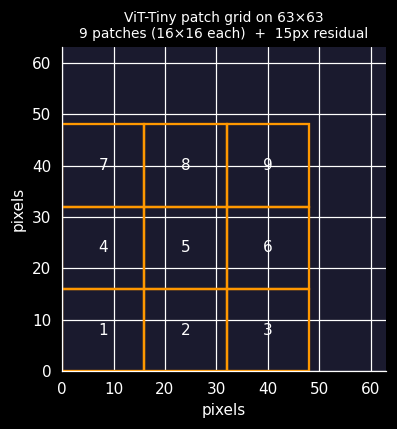

In [8]:
vit_model = ViTTiny('real_bogus').eval()

# Show patch embedding grid
patch_size = 16
n_patches_side = IMG_SIZE // patch_size
n_patches = n_patches_side ** 2
print(f'Image size:           {IMG_SIZE}×{IMG_SIZE}')
print(f'Patch size:           {patch_size}×{patch_size}')
print(f'Patches per side:     {n_patches_side}')
print(f'Total spatial tokens: {n_patches}')
print(f'+ CLS token →         {n_patches + 1} tokens total')

# Peek at the timm config
cfg = vit_model.net.pretrained_cfg if hasattr(vit_model.net, 'pretrained_cfg') else {}
print(f'\nParameters:  {count_parameters(vit_model)["total"]/1e6:.2f} M')

# Visualise the patch grid over an example triplet
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.set_xlim(0, IMG_SIZE)
ax.set_ylim(0, IMG_SIZE)
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
for i in range(n_patches_side):
    for j in range(n_patches_side):
        rect = patches.Rectangle(
            (j * patch_size, i * patch_size), patch_size, patch_size,
            linewidth=1.5, edgecolor='#FF9800', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(j * patch_size + patch_size/2, i * patch_size + patch_size/2,
                str(i * n_patches_side + j + 1),
                ha='center', va='center', color='white', fontsize=10)
# Residual pixels outside the patch grid
residual = IMG_SIZE - n_patches_side * patch_size
ax.set_title(
    f'ViT-Tiny patch grid on 63×63\n'
    f'{n_patches} patches (16×16 each)  +  {residual}px residual',
    fontsize=9
)
ax.set_xlabel('pixels')
ax.set_ylabel('pixels')
plt.tight_layout()
plt.savefig('../results/vit_patch_grid.png', bbox_inches='tight', dpi=120)
plt.show()

## 8 — Receptive Field & Coverage Analysis

A rough estimate of the effective receptive field (ERF) at each depth for ResNet-18, and how much of the 63×63 image is 'seen' at each layer.

For CNNs: ERF grows approximately as `r = k + (k-1) × (2^depth - 1)` for stride-1 layers and doubles at each stride-2 layer.  For ViT-Tiny, every token attends globally from layer 1 — the receptive field is the full image from the start.

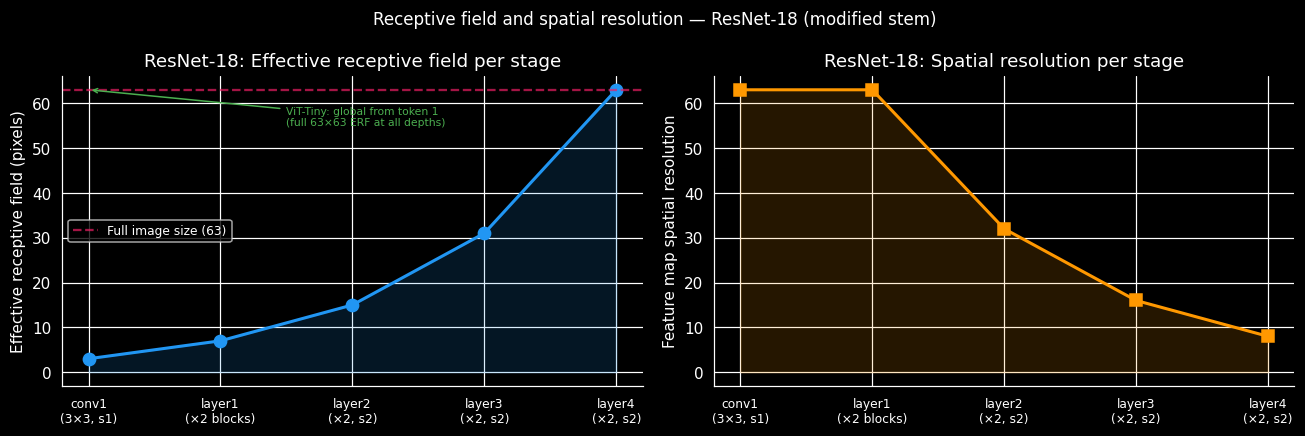

In [9]:
# ResNet-18 receptive field (modified stem = 3x3 stride-1)
# Each basic block has two 3×3 convs; stride-2 layers double spatial jump
layers = ['conv1\n(3×3, s1)', 'layer1\n(×2 blocks)', 'layer2\n(×2, s2)',
          'layer3\n(×2, s2)', 'layer4\n(×2, s2)']
erf = [3, 7, 15, 31, 63]   # approximate ERFs for our modified architecture
spatial_res = [63, 63, 32, 16, 8]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ERF
ax1.plot(layers, erf, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.axhline(63, color='#E91E63', linestyle='--', alpha=0.7, label='Full image size (63)')
ax1.fill_between(range(len(layers)), erf,
                 alpha=0.15, color='#2196F3')
ax1.set_ylabel('Effective receptive field (pixels)')
ax1.set_title('ResNet-18: Effective receptive field per stage')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=0)
ax1.set_xticks(range(len(layers)))
ax1.set_xticklabels(layers, fontsize=8)

# Spatial resolution
ax2.plot(layers, spatial_res, 's-', color='#FF9800', linewidth=2, markersize=8)
ax2.fill_between(range(len(layers)), spatial_res, alpha=0.15, color='#FF9800')
ax2.set_ylabel('Feature map spatial resolution')
ax2.set_title('ResNet-18: Spatial resolution per stage')
ax2.tick_params(axis='x', rotation=0)
ax2.set_xticks(range(len(layers)))
ax2.set_xticklabels(layers, fontsize=8)

# Annotate ViT comparison
ax1.annotate('ViT-Tiny: global from token 1\n(full 63×63 ERF at all depths)',
             xy=(0, 63), xytext=(1.5, 55),
             fontsize=7, color='#4CAF50',
             arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=1))

plt.suptitle('Receptive field and spatial resolution — ResNet-18 (modified stem)',
             fontsize=11)
plt.tight_layout()
plt.savefig('../results/receptive_field.png', bbox_inches='tight', dpi=120)
plt.show()

## 9 — Forward-Pass Profiling (GPU)

Measure wall-clock inference speed and peak VRAM usage per model at batch size 64.
This guides the batch size choice for training on the RTX 4060 (8 GB).

          Model Params (M) Fwd pass (ms, BS=64) Throughput (samples/s) Peak VRAM (MB)
   ResNet-18 RB      11.17                 38.5                   1664            382
   ResNet-18 MC      11.17                 38.4                   1665            382
EfficientNet-B0       4.01                  5.9                  10787             91
       ViT-Tiny       5.49                  2.6                  24632             40


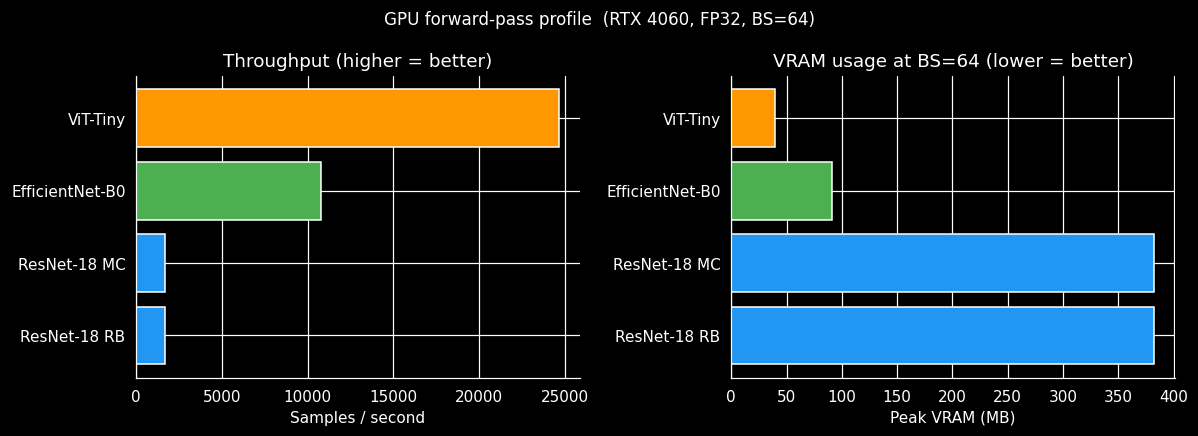

In [10]:
import time

if DEVICE.type != 'cuda':
    print('CUDA not available — skipping GPU profiling.')
else:
    BATCH_SIZE = 64
    WARMUP     = 5
    REPEATS    = 20

    profile_configs = [
        ('ResNet-18 RB',     RealBogusResNet18()),
        ('ResNet-18 MC',     TransientResNet18()),
        ('EfficientNet-B0',  EfficientNetB0('real_bogus')),
        ('ViT-Tiny',         ViTTiny('real_bogus')),
    ]
    results = []
    x_gpu = torch.randn(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

    for name, model in profile_configs:
        model = model.to(DEVICE).eval()
        torch.cuda.reset_peak_memory_stats()
        # Warmup
        with torch.no_grad():
            for _ in range(WARMUP):
                _ = model(x_gpu)
        torch.cuda.synchronize()
        # Timed run
        t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(REPEATS):
                _ = model(x_gpu)
        torch.cuda.synchronize()
        elapsed_ms = (time.perf_counter() - t0) / REPEATS * 1000
        peak_mb = torch.cuda.max_memory_allocated() / 1e6
        throughput = BATCH_SIZE / (elapsed_ms / 1000)
        params_M = count_parameters(model)['total'] / 1e6
        results.append({
            'Model': name,
            'Params (M)': f'{params_M:.2f}',
            'Fwd pass (ms, BS=64)': f'{elapsed_ms:.1f}',
            'Throughput (samples/s)': f'{throughput:.0f}',
            'Peak VRAM (MB)': f'{peak_mb:.0f}',
        })
        model.cpu()
        torch.cuda.empty_cache()

    df_profile = pd.DataFrame(results)
    print(df_profile.to_string(index=False))

    # Bar chart — throughput
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    names  = [r['Model'] for r in results]
    tput   = [float(r['Throughput (samples/s)']) for r in results]
    vram   = [float(r['Peak VRAM (MB)']) for r in results]
    clrs   = ['#2196F3', '#2196F3', '#4CAF50', '#FF9800']

    ax1.barh(names, tput, color=clrs)
    ax1.set_xlabel('Samples / second')
    ax1.set_title('Throughput (higher = better)')
    ax2.barh(names, vram, color=clrs)
    ax2.set_xlabel('Peak VRAM (MB)')
    ax2.set_title('VRAM usage at BS=64 (lower = better)')
    plt.suptitle('GPU forward-pass profile  (RTX 4060, FP32, BS=64)', fontsize=11)
    plt.tight_layout()
    plt.savefig('../results/gpu_profile.png', bbox_inches='tight', dpi=120)
    plt.show()

## 10 — Output Head Activations (Sanity Check)

Verify that freshly-initialised models produce valid pre-training distributions:

- **Binary**: sigmoid output should be uniformly distributed around 0.5
- **Multiclass**: softmax output should be roughly uniform across the 5 classes

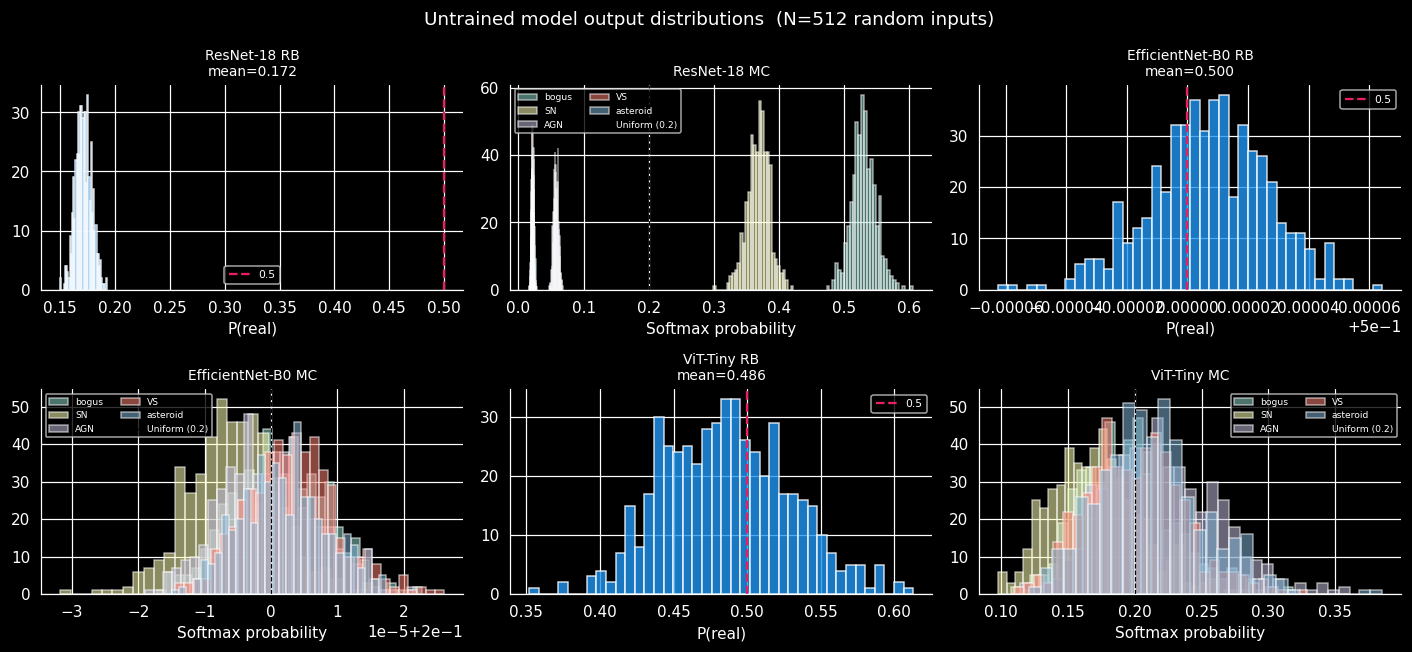

In [11]:
torch.manual_seed(42)
N = 512  # synthetic samples
x_batch = torch.randn(N, 3, IMG_SIZE, IMG_SIZE)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.flatten()

configs_head = [
    ('ResNet-18 RB',        RealBogusResNet18(),     'real_bogus'),
    ('ResNet-18 MC',        TransientResNet18(),     'multiclass'),
    ('EfficientNet-B0 RB',  EfficientNetB0('real_bogus'), 'real_bogus'),
    ('EfficientNet-B0 MC',  EfficientNetB0('multiclass'), 'multiclass'),
    ('ViT-Tiny RB',         ViTTiny('real_bogus'),   'real_bogus'),
    ('ViT-Tiny MC',         ViTTiny('multiclass'),   'multiclass'),
]

for ax, (name, model, task) in zip(axes, configs_head):
    model.eval()
    with torch.no_grad():
        probs = model.predict_proba(x_batch).cpu().numpy()

    if task == 'real_bogus':
        ax.hist(probs, bins=40, color='#2196F3', edgecolor='white', alpha=0.8)
        ax.axvline(0.5, color='#E91E63', linestyle='--', label='0.5')
        ax.set_xlabel('P(real)')
        ax.set_title(name)
        ax.legend(fontsize=7)
        mean_p = probs.mean()
        ax.set_title(f'{name}\nmean={mean_p:.3f}', fontsize=9)
    else:
        # probs shape (N, 5)
        for c_idx, c_name in enumerate(CLASS_NAMES):
            ax.hist(probs[:, c_idx], bins=30, alpha=0.55, label=c_name)
        ax.axvline(1/5, color='black', linestyle='--', linewidth=0.8, label='Uniform (0.2)')
        ax.set_xlabel('Softmax probability')
        ax.set_title(name, fontsize=9)
        ax.legend(fontsize=6, ncol=2)

plt.suptitle('Untrained model output distributions  (N=512 random inputs)',
             fontsize=12)
plt.tight_layout()
plt.savefig('../results/output_head_distributions.png', bbox_inches='tight', dpi=120)
plt.show()

## 11 — Summary

In [12]:
print('='*60)
print('  STAGE 6 — MODEL ARCHITECTURE SUMMARY')
print('='*60)

summary_rows = model_summary_table()
print(f'\n{"Model":<20} {"Task":<12} {"Params":<10} {"Input":<14} {"Output":<10}')
print('-'*66)
for r in summary_rows:
    print(f"{r['name']:<20} {r['task']:<12} {r['params_M']:<10.2f} "
          f"{r['input_shape']:<14} {r['output_shape']:<10}")

print('\nKey architectural decisions:')
print('  1. ResNet-18 stem: 7×7 stride-2 → 3×3 stride-1 (preserves 63×63 resolution)')
print('  2. MaxPool removed: replaced with Identity (no aggressive downsampling)')
print('  3. EfficientNet-B0: no structural changes; adaptive avgpool handles 63×63')
print('  4. ViT-Tiny: img_size=63 → 9 patches of 16×16 + CLS = 10 tokens')
print('  5. All models: Dropout(0.4) before output head to regularise small training sets')

print('\nFor ablation studies (spec §11 Ablation 2):')
print('  - ResNet-18 (11.2 M) vs EfficientNet-B0 (4.0 M) vs ViT-Tiny (5.5 M)')
print('  - Hypothesis: EfficientNet-B0 achieves comparable AUC with fewer params')
print('  - ViT: global attention from token 1 — useful if classification relies')
print('    on whole-image context (e.g. galaxy morphology for AGN vs SN)')

print('\nNext steps:')
print('  → Stage 7 (Handling Class Imbalance): FocalLoss + WeightedSampler')
print('  → Stage 8 (Training): mixed-precision training loop with AdamW + CosineAnnealingLR')

  STAGE 6 — MODEL ARCHITECTURE SUMMARY

Model                Task         Params     Input          Output    
------------------------------------------------------------------
resnet18_rb          real_bogus   11.17      (3, 63, 63)    ()        
resnet18_mc          multiclass   11.17      (3, 63, 63)    (5,)      
efficientnet_b0      real_bogus   4.01       (3, 63, 63)    ()        
efficientnet_b0      multiclass   4.01       (3, 63, 63)    (5,)      
vit_tiny             real_bogus   5.49       (3, 63, 63)    ()        
vit_tiny             multiclass   5.49       (3, 63, 63)    (5,)      

Key architectural decisions:
  1. ResNet-18 stem: 7×7 stride-2 → 3×3 stride-1 (preserves 63×63 resolution)
  2. MaxPool removed: replaced with Identity (no aggressive downsampling)
  3. EfficientNet-B0: no structural changes; adaptive avgpool handles 63×63
  4. ViT-Tiny: img_size=63 → 9 patches of 16×16 + CLS = 10 tokens
  5. All models: Dropout(0.4) before output head to regularise small tra